# 🏠 Análise de Preços de Casas nos Estados Unidos
**Desafio de Machine Learning - FAESA Centro Universitário**

Este notebook cobre todas as etapas do desafio:
1. Análise Exploratória de Dados (EDA) e Feature Engineering
2. Aprendizagem Supervisionada: Regressão
3. Aprendizagem Supervisionada: Classificação
4. Aprendizagem Não Supervisionada: Clusterização
5. Aprendizagem Não Supervisionada: Redução de Dimensionalidade
6. Aprendizagem Não Supervisionada: Análise de Associação e Outlier
7. Visualização de Dados

In [1]:
# ============================================================
# INSTALAÇÃO DE DEPENDÊNCIAS (rode apenas uma vez)
# ============================================================
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost mlxtend

In [2]:
# ============================================================
# IMPORTS GERAIS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Imports realizados com sucesso!')

✅ Imports realizados com sucesso!


---
## 📂 Carregamento dos Dados

In [3]:
# ⚠️ ATENÇÃO: coloque o arquivo train.csv na mesma pasta deste notebook
df = pd.read_csv('train.csv')
print(f'Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head()

Dataset carregado: 1460 linhas × 81 colunas


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## 1️⃣ Análise Exploratória de Dados (EDA) e Feature Engineering

In [4]:
# --------------------------------------------------------------
# 1.1 Informações gerais
# --------------------------------------------------------------
print('=== TIPOS DE DADOS ===')
print(f'Colunas numéricas: {df.select_dtypes(include=np.number).shape[1]}')
print(f'Colunas categóricas: {df.select_dtypes(include=object).shape[1]}')
print()
df.info()

=== TIPOS DE DADOS ===
Colunas numéricas: 38
Colunas categóricas: 43

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-nu

In [5]:
# --------------------------------------------------------------
# 1.2 Estatísticas descritivas
# --------------------------------------------------------------
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


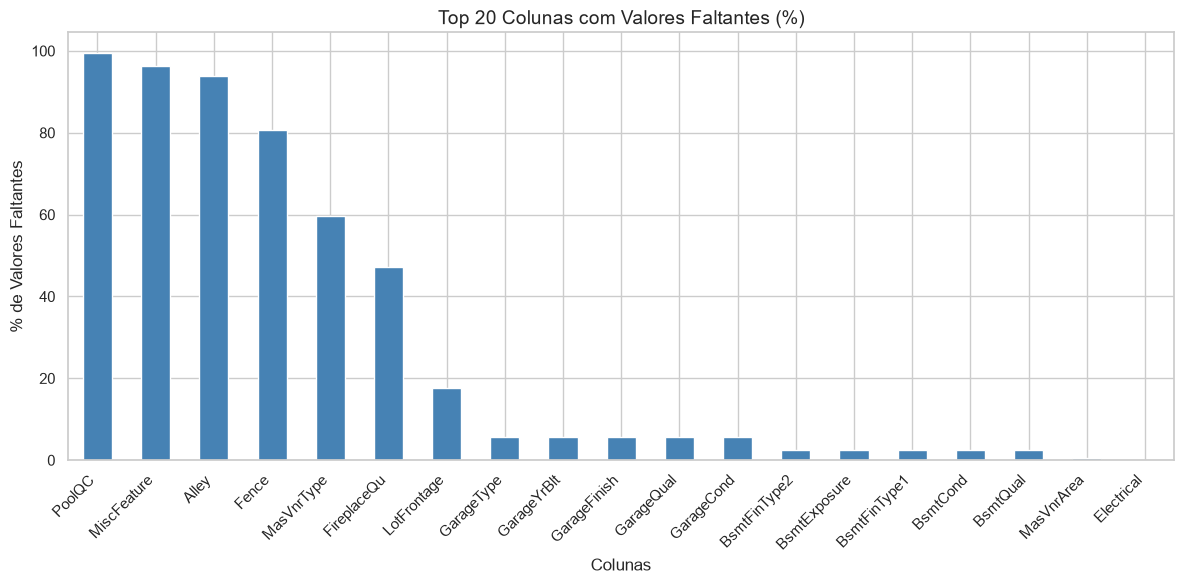

              Missing  % Missing
PoolQC           1453      99.52
MiscFeature      1406      96.30
Alley            1369      93.77
Fence            1179      80.75
MasVnrType        872      59.73
FireplaceQu       690      47.26
LotFrontage       259      17.74
GarageType         81       5.55
GarageYrBlt        81       5.55
GarageFinish       81       5.55
GarageQual         81       5.55
GarageCond         81       5.55
BsmtFinType2       38       2.60
BsmtExposure       38       2.60
BsmtFinType1       37       2.53
BsmtCond           37       2.53
BsmtQual           37       2.53
MasVnrArea          8       0.55
Electrical          1       0.07


In [6]:
# --------------------------------------------------------------
# 1.3 Valores faltantes
# --------------------------------------------------------------
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 6))
missing_pct.head(20).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 20 Colunas com Valores Faltantes (%)', fontsize=14)
ax.set_ylabel('% de Valores Faltantes')
ax.set_xlabel('Colunas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'Missing': missing, '% Missing': missing_pct}).head(20))

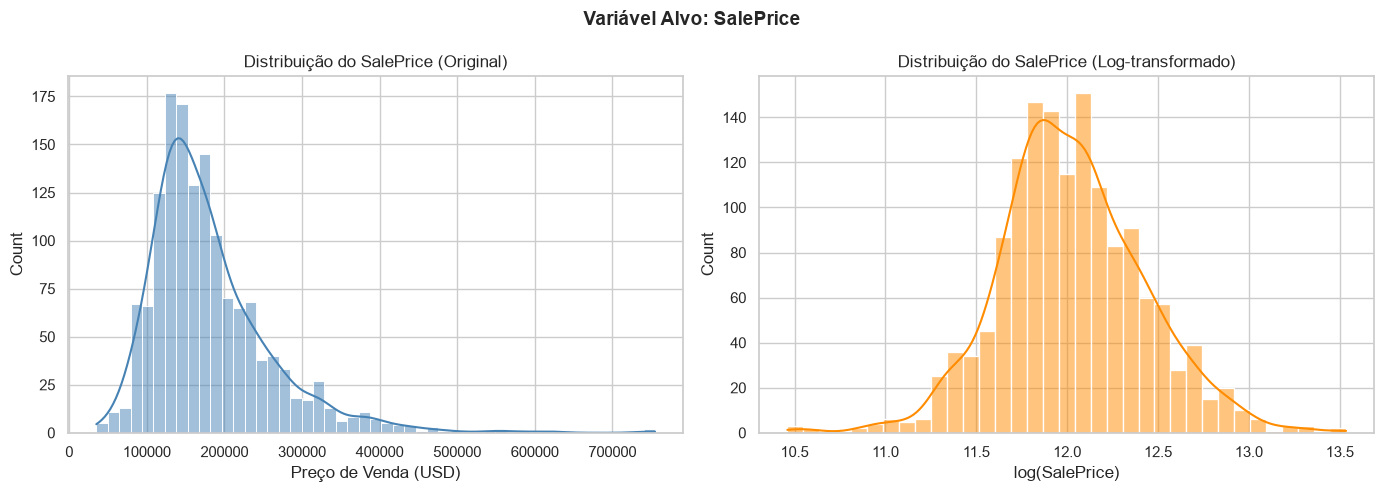

Assimetria original: 1.883
Assimetria log: 0.121


In [7]:
# --------------------------------------------------------------
# 1.4 Distribuição da variável alvo: SalePrice
# --------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição do SalePrice (Original)')
axes[0].set_xlabel('Preço de Venda (USD)')

sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribuição do SalePrice (Log-transformado)')
axes[1].set_xlabel('log(SalePrice)')

plt.suptitle('Variável Alvo: SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Assimetria original: {df["SalePrice"].skew():.3f}')
print(f'Assimetria log: {np.log1p(df["SalePrice"]).skew():.3f}')

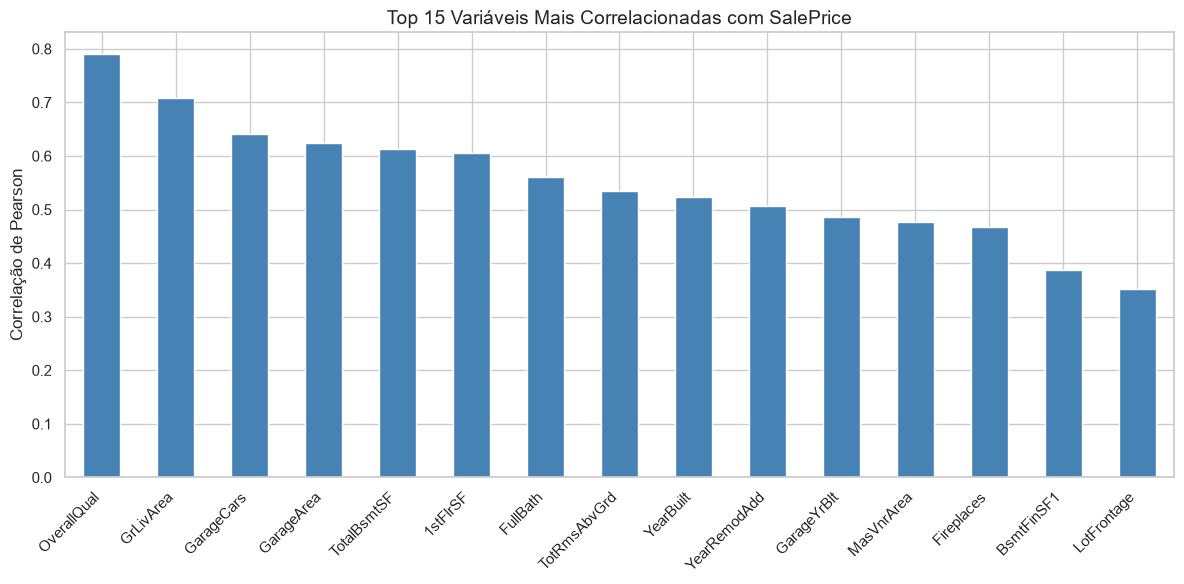

In [8]:
# --------------------------------------------------------------
# 1.5 Correlação com SalePrice (top variáveis numéricas)
# --------------------------------------------------------------
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
corr.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 15 Variáveis Mais Correlacionadas com SalePrice', fontsize=14)
ax.set_ylabel('Correlação de Pearson')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

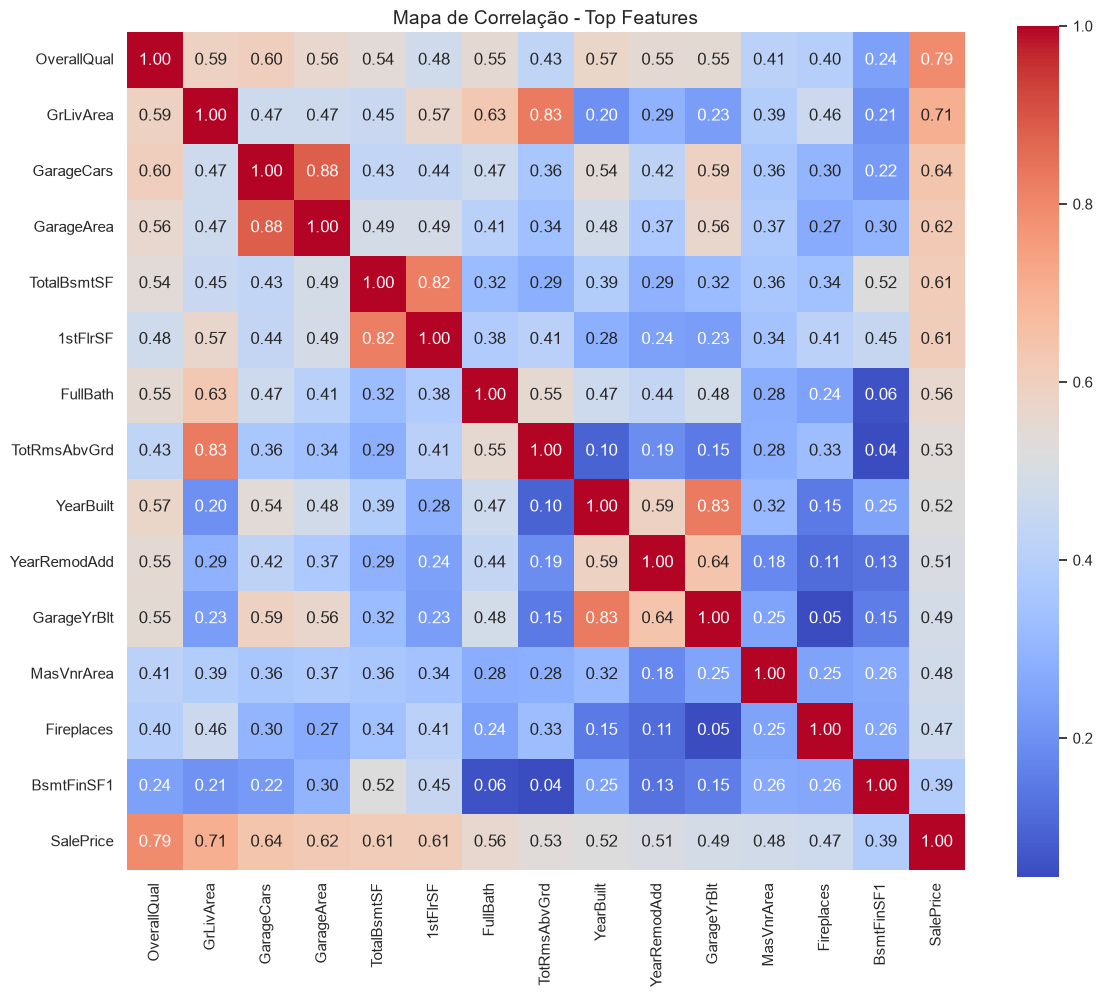

In [9]:
# --------------------------------------------------------------
# 1.6 Heatmap de correlação (top 15 features)
# --------------------------------------------------------------
top_features = corr.head(14).index.tolist() + ['SalePrice']

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    df[top_features].corr(), annot=True, fmt='.2f',
    cmap='coolwarm', ax=ax, square=True
)
ax.set_title('Mapa de Correlação - Top Features', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# --------------------------------------------------------------
# 1.7 FEATURE ENGINEERING
# --------------------------------------------------------------
df_fe = df.copy()

# 1) Remover colunas com > 45% de valores faltantes
high_missing = missing_pct[missing_pct > 45].index.tolist()
df_fe.drop(columns=high_missing, inplace=True)
print(f'Colunas removidas (>45% missing): {high_missing}')

# 2) Criar nova feature: Área total (porão + 1º andar + 2º andar)
df_fe['TotalSF'] = df_fe['TotalBsmtSF'].fillna(0) + df_fe['1stFlrSF'] + df_fe['2ndFlrSF']

# 3) Idade da casa no momento da venda
df_fe['HouseAge'] = df_fe['YrSold'] - df_fe['YearBuilt']

# 4) Anos desde última reforma
df_fe['YearsSinceRemodel'] = df_fe['YrSold'] - df_fe['YearRemodAdd']

# 5) Total de banheiros
df_fe['TotalBath'] = (
    df_fe['FullBath'] + 0.5 * df_fe['HalfBath'] +
    df_fe.get('BsmtFullBath', pd.Series(0, index=df_fe.index)).fillna(0) +
    0.5 * df_fe.get('BsmtHalfBath', pd.Series(0, index=df_fe.index)).fillna(0)
)

# 6) Preencher valores faltantes numéricos com mediana
for col in df_fe.select_dtypes(include=np.number).columns:
    df_fe[col].fillna(df_fe[col].median(), inplace=True)

# 7) Preencher valores faltantes categóricos com 'None'
for col in df_fe.select_dtypes(include=object).columns:
    df_fe[col].fillna('None', inplace=True)

# 8) Codificar variáveis categóricas (Label Encoding)
le = LabelEncoder()
cat_cols = df_fe.select_dtypes(include=object).columns
for col in cat_cols:
    df_fe[col] = le.fit_transform(df_fe[col].astype(str))

print(f'\nDataset após Feature Engineering: {df_fe.shape[0]} linhas × {df_fe.shape[1]} colunas')
print(f'Valores faltantes restantes: {df_fe.isnull().sum().sum()}')

Colunas removidas (>45% missing): ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']

Dataset após Feature Engineering: 1460 linhas × 79 colunas
Valores faltantes restantes: 0


---
## 2️⃣ Aprendizagem Supervisionada — Regressão

In [11]:
# --------------------------------------------------------------
# 2.1 Preparação dos dados para regressão
# --------------------------------------------------------------
X = df_fe.drop(columns=['SalePrice', 'Id'])
y = np.log1p(df_fe['SalePrice'])  # transformação log para reduzir assimetria

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (1168, 77) | Teste: (292, 77)


In [12]:
# --------------------------------------------------------------
# 2.2 Regressão Linear
# --------------------------------------------------------------
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('📊 Regressão Linear:')
print(f'  MAE : {mae_lr:.4f}')
print(f'  RMSE: {rmse_lr:.4f}')
print(f'  R²  : {r2_lr:.4f}')

📊 Regressão Linear:
  MAE : 0.1065
  RMSE: 0.1548
  R²  : 0.8715


In [13]:
# --------------------------------------------------------------
# 2.3 Random Forest Regressor
# --------------------------------------------------------------
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('📊 Random Forest Regressor:')
print(f'  MAE : {mae_rf:.4f}')
print(f'  RMSE: {rmse_rf:.4f}')
print(f'  R²  : {r2_rf:.4f}')

📊 Random Forest Regressor:
  MAE : 0.0966
  RMSE: 0.1445
  R²  : 0.8882


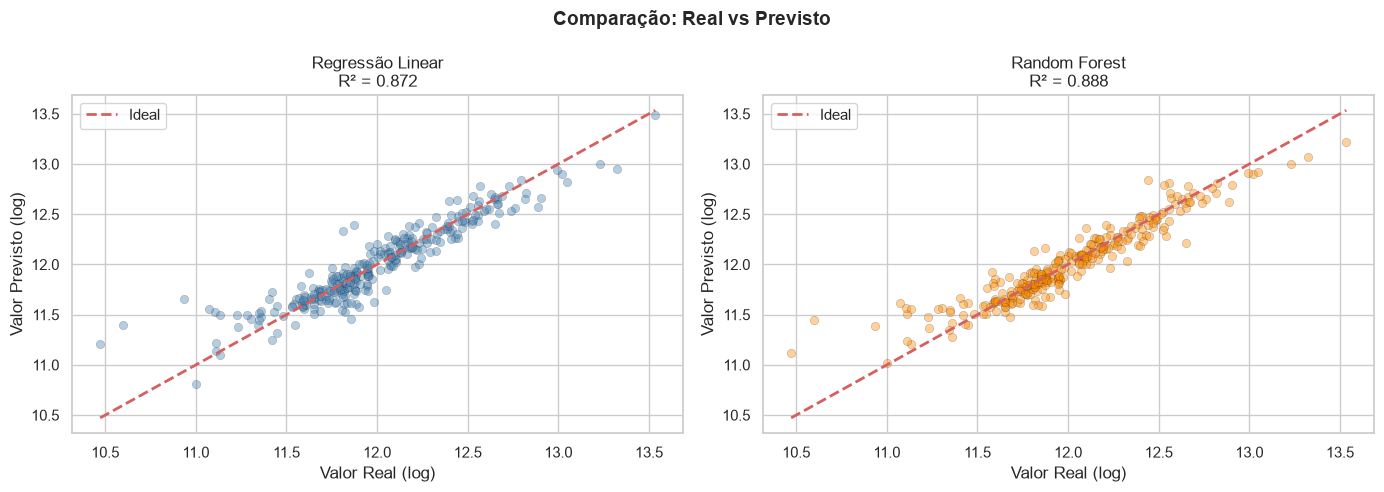

In [14]:
# --------------------------------------------------------------
# 2.4 Visualização: Real vs Previsto
# --------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Regressão Linear', 'Random Forest'],
    ['steelblue', 'darkorange']
):
    ax.scatter(y_test, y_pred, alpha=0.4, color=color, edgecolors='k', linewidths=0.3)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Ideal')
    ax.set_title(f'{title}\nR² = {r2_score(y_test, y_pred):.3f}')
    ax.set_xlabel('Valor Real (log)')
    ax.set_ylabel('Valor Previsto (log)')
    ax.legend()

plt.suptitle('Comparação: Real vs Previsto', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

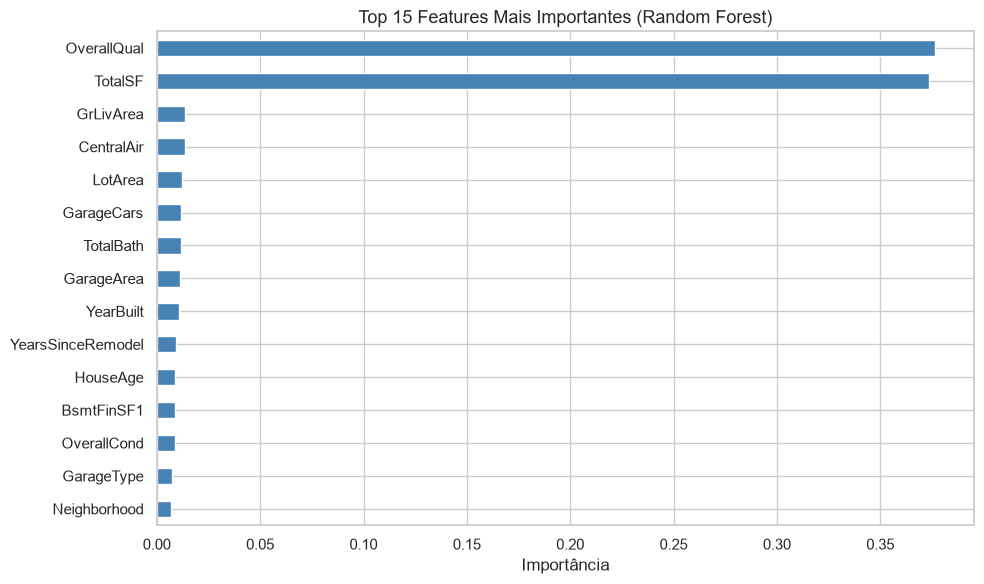

In [15]:
# --------------------------------------------------------------
# 2.5 Feature Importance (Random Forest)
# --------------------------------------------------------------
importances = pd.Series(rf_reg.feature_importances_, index=X.columns)
importances_top = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 6))
importances_top.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Features Mais Importantes (Random Forest)', fontsize=13)
ax.set_xlabel('Importância')
plt.tight_layout()
plt.show()

---
## 3️⃣ Aprendizagem Supervisionada — Classificação

In [16]:
# --------------------------------------------------------------
# 3.1 Criar variável binária: preço alto (1) ou baixo (0)
# mediana como threshold
# --------------------------------------------------------------
median_price = df_fe['SalePrice'].median()
y_class = (df_fe['SalePrice'] >= median_price).astype(int)

print(f'Mediana do SalePrice: USD {median_price:,.0f}')
print(f'Casas de preço ALTO (1): {y_class.sum()} ({y_class.mean()*100:.1f}%)')
print(f'Casas de preço BAIXO (0): {(1-y_class).sum()} ({(1-y_class).mean()*100:.1f}%)')

X_tr, X_te, y_tr, y_te = train_test_split(X, y_class, test_size=0.2, random_state=42)
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

Mediana do SalePrice: USD 163,000
Casas de preço ALTO (1): 732 (50.1%)
Casas de preço BAIXO (0): 728 (49.9%)


In [17]:
# --------------------------------------------------------------
# 3.2 Treinar múltiplos classificadores
# --------------------------------------------------------------
classifiers = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results_clf = {}
for name, clf in classifiers.items():
    if name in ['Regressão Logística', 'KNN']:
        clf.fit(X_tr_sc, y_tr)
        y_pred = clf.predict(X_te_sc)
    else:
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
    
    results_clf[name] = {
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1-Score' : f1_score(y_te, y_pred),
    }

df_results = pd.DataFrame(results_clf).T.round(4)
print('📊 Comparação dos Classificadores:')
df_results

📊 Comparação dos Classificadores:


,Accuracy,Precision,Recall,F1-Score
Regressão Logística,0.9452,0.9259,0.9542,0.9398
KNN,0.9452,0.9389,0.9389,0.9389
Árvore de Decisão,0.8870,0.8500,0.9084,0.8782
Random Forest,0.9418,0.9254,0.9466,0.9358


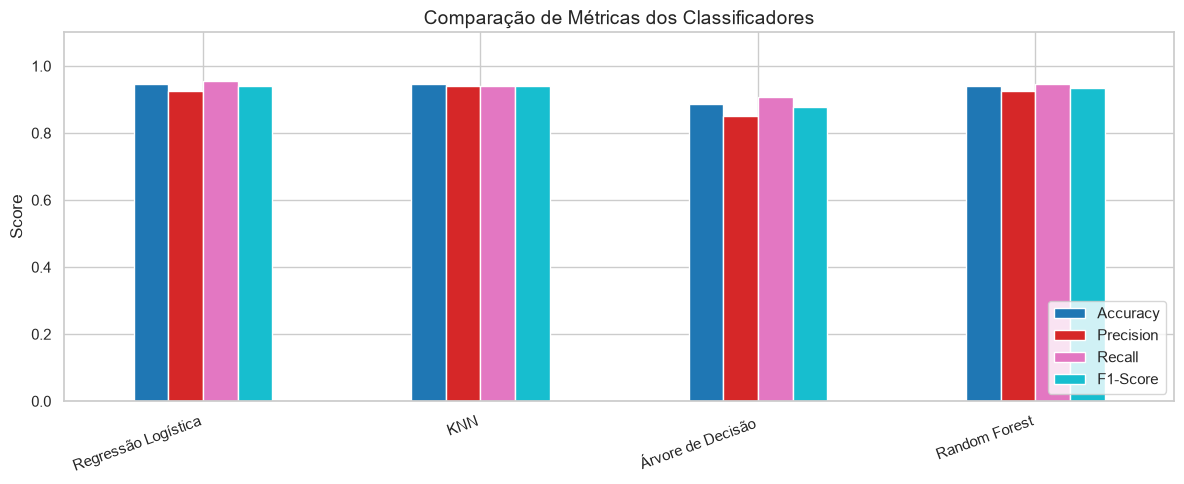

In [18]:
# --------------------------------------------------------------
# 3.3 Visualização: Comparação de métricas
# --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
df_results.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Comparação de Métricas dos Classificadores', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_xticklabels(df_results.index, rotation=20, ha='right')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

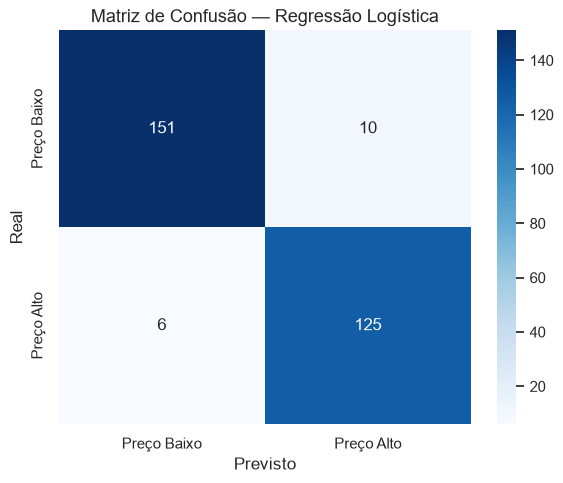


Melhor modelo: Regressão Logística
              precision    recall  f1-score   support

       Baixo       0.96      0.94      0.95       161
        Alto       0.93      0.95      0.94       131

    accuracy                           0.95       292
   macro avg       0.94      0.95      0.94       292
weighted avg       0.95      0.95      0.95       292



In [19]:
# --------------------------------------------------------------
# 3.4 Matriz de Confusão (melhor modelo)
# --------------------------------------------------------------
best_clf_name = df_results['F1-Score'].idxmax()
best_clf = classifiers[best_clf_name]
if best_clf_name in ['Regressão Logística', 'KNN']:
    y_pred_best = best_clf.predict(X_te_sc)
else:
    y_pred_best = best_clf.predict(X_te)

cm = confusion_matrix(y_te, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Preço Baixo', 'Preço Alto'],
            yticklabels=['Preço Baixo', 'Preço Alto'])
ax.set_title(f'Matriz de Confusão — {best_clf_name}', fontsize=13)
ax.set_ylabel('Real')
ax.set_xlabel('Previsto')
plt.tight_layout()
plt.show()

print(f'\nMelhor modelo: {best_clf_name}')
print(classification_report(y_te, y_pred_best, target_names=['Baixo', 'Alto']))

---
## 4️⃣ Aprendizagem Não Supervisionada — Clusterização (K-Means)

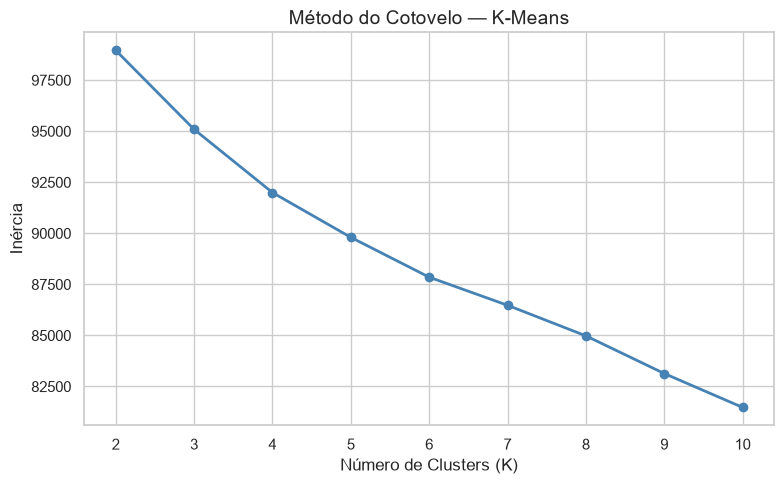

In [20]:
# --------------------------------------------------------------
# 4.1 Método do Cotovelo para escolher K
# --------------------------------------------------------------
X_cluster = scaler.fit_transform(X)

inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
ax.set_title('Método do Cotovelo — K-Means', fontsize=14)
ax.set_xlabel('Número de Clusters (K)')
ax.set_ylabel('Inércia')
plt.tight_layout()
plt.show()

In [21]:
# --------------------------------------------------------------
# 4.2 K-Means com K=4
# --------------------------------------------------------------
K_BEST = 4
kmeans = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

df_cluster = df_fe.copy()
df_cluster['Cluster'] = clusters

# Análise por cluster
cluster_summary = df_cluster.groupby('Cluster')['SalePrice'].agg(['mean', 'median', 'count'])
cluster_summary.columns = ['Média', 'Mediana', 'Contagem']
cluster_summary['Média'] = cluster_summary['Média'].map('US${:,.0f}'.format)
cluster_summary['Mediana'] = cluster_summary['Mediana'].map('US${:,.0f}'.format)
print('📊 Resumo dos Clusters por SalePrice:')
print(cluster_summary)

📊 Resumo dos Clusters por SalePrice:
              Média     Mediana  Contagem
Cluster                                  
0        US$148,292  US$143,000       541
1        US$121,874  US$117,000       316
2        US$322,671  US$309,000       199
3        US$200,979  US$194,600       404


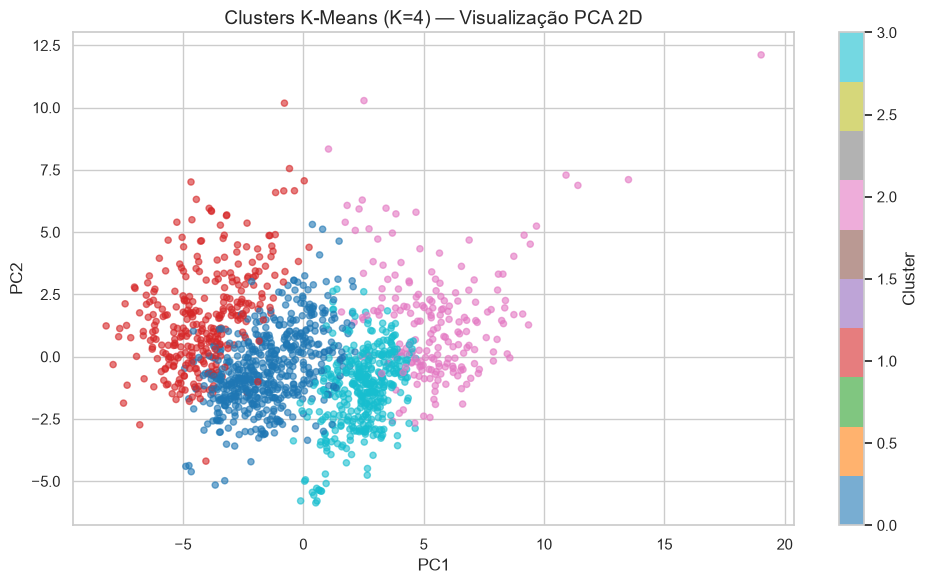

In [22]:
# --------------------------------------------------------------
# 4.3 Visualização dos Clusters (PCA 2D)
# --------------------------------------------------------------
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_cluster)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters,
                     cmap='tab10', alpha=0.6, s=20)
ax.set_title(f'Clusters K-Means (K={K_BEST}) — Visualização PCA 2D', fontsize=14)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

---
## 5️⃣ Aprendizagem Não Supervisionada — Redução de Dimensionalidade (PCA)

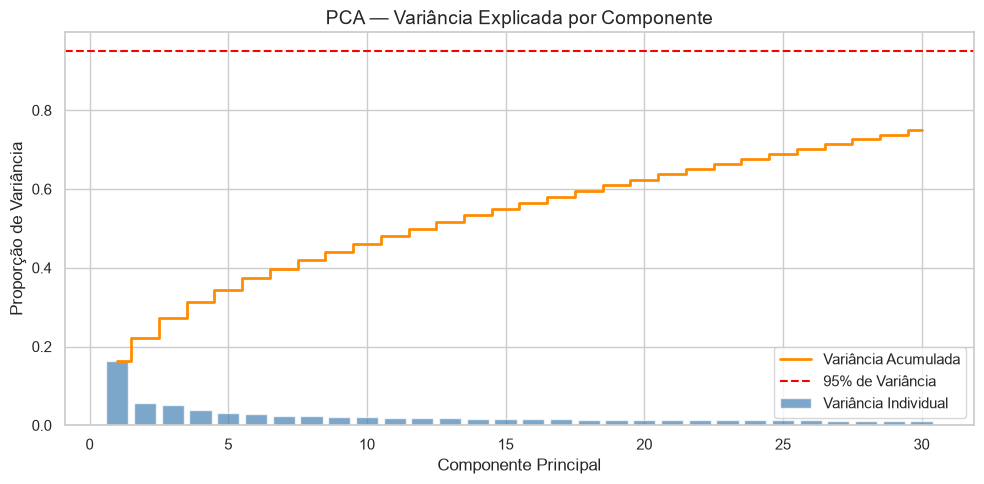

Componentes necessários para 95% de variância: 55


In [23]:
# --------------------------------------------------------------
# 5.1 PCA — Variância Explicada
# --------------------------------------------------------------
pca_full = PCA(random_state=42)
pca_full.fit(X_cluster)

var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)
n_95 = np.argmax(var_cum >= 0.95) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 31), var_exp[:30], alpha=0.7, color='steelblue', label='Variância Individual')
ax.step(range(1, 31), var_cum[:30], where='mid', color='darkorange',
        linewidth=2, label='Variância Acumulada')
ax.axhline(0.95, color='red', linestyle='--', label='95% de Variância')
ax.set_title('PCA — Variância Explicada por Componente', fontsize=14)
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Proporção de Variância')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Componentes necessários para 95% de variância: {n_95}')

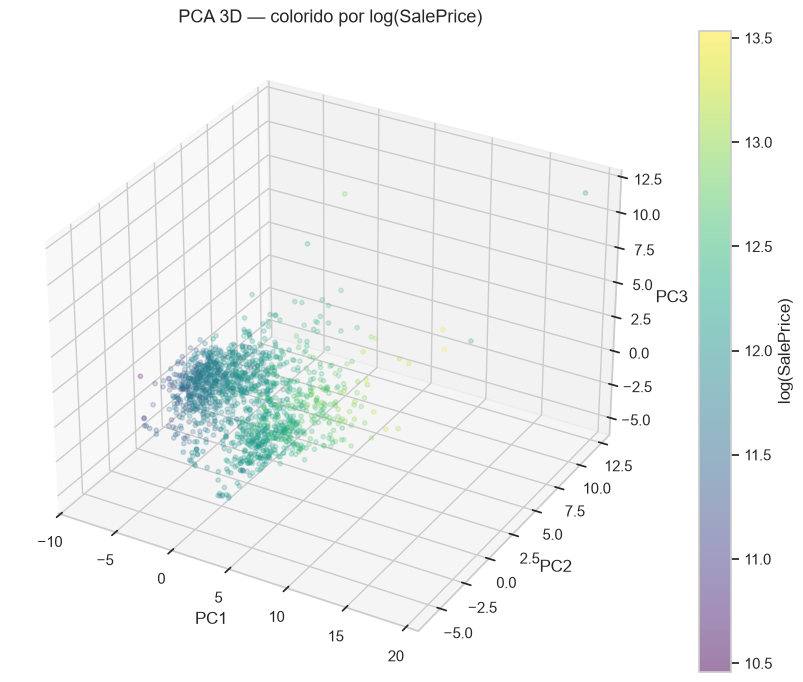

In [24]:
# --------------------------------------------------------------
# 5.2 PCA 3D — Visualização colorida por SalePrice
# --------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3, random_state=42)
X_3d = pca3.fit_transform(X_cluster)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
                c=np.log1p(df_fe['SalePrice']), cmap='viridis',
                alpha=0.5, s=10)
plt.colorbar(sc, ax=ax, label='log(SalePrice)')
ax.set_title('PCA 3D — colorido por log(SalePrice)', fontsize=13)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.tight_layout()
plt.show()

---
## 6️⃣ Aprendizagem Não Supervisionada — Análise de Associação e Outlier

In [25]:
# --------------------------------------------------------------
# 6.1 Análise de Associação (Apriori)
# Usamos variáveis categóricas do dataset original
# --------------------------------------------------------------
cat_features = ['MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle', 'ExterQual', 'KitchenQual']

# Manter apenas colunas que existem no df original
cat_features = [c for c in cat_features if c in df.columns]

# Discretizar SalePrice em categoria
df_assoc = df[cat_features].copy()
df_assoc['PriceCategory'] = pd.cut(
    df['SalePrice'],
    bins=[0, 120000, 200000, 1e9],
    labels=['Barato', 'Médio', 'Caro']
)

# Converter para lista de transações
transactions = []
for _, row in df_assoc.iterrows():
    transaction = [f"{col}={val}" for col, val in row.items() if pd.notna(val)]
    transactions.append(transaction)

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

# Apriori
frequent_itemsets = apriori(df_trans, min_support=0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.6)
rules = rules.sort_values('lift', ascending=False)

print(f'Regras encontradas: {len(rules)}')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Regras encontradas: 546


,antecedents,consequents,support,confidence,lift
435,"(KitchenQual=Gd, PriceCategory=Caro, MSZoning=RL)","(BldgType=1Fam, ExterQual=Gd)",0.139726,0.775665,2.845406
437,"(KitchenQual=Gd, PriceCategory=Caro)","(BldgType=1Fam, ExterQual=Gd, MSZoning=RL)",0.139726,0.684564,2.815389
229,"(KitchenQual=Gd, PriceCategory=Caro)","(BldgType=1Fam, ExterQual=Gd)",0.156164,0.765101,2.806651
374,"(KitchenQual=Gd, PriceCategory=Caro)","(ExterQual=Gd, MSZoning=RL)",0.152055,0.744966,2.698886
431,"(BldgType=1Fam, KitchenQual=Gd, PriceCategory=...","(ExterQual=Gd, MSZoning=RL)",0.139726,0.744526,2.697289
372,"(KitchenQual=Gd, PriceCategory=Caro, MSZoning=RL)",(ExterQual=Gd),0.152055,0.844106,2.525400
140,"(KitchenQual=Gd, PriceCategory=Caro)",(ExterQual=Gd),0.171918,0.842282,2.519942
427,"(BldgType=1Fam, KitchenQual=Gd, PriceCategory=...",(ExterQual=Gd),0.139726,0.832653,2.491134
225,"(BldgType=1Fam, KitchenQual=Gd, PriceCategory=...",(ExterQual=Gd),0.156164,0.832117,2.489530
212,"(KitchenQual=Gd, HouseStyle=2Story)","(BldgType=1Fam, ExterQual=Gd)",0.109589,0.663900,2.435414


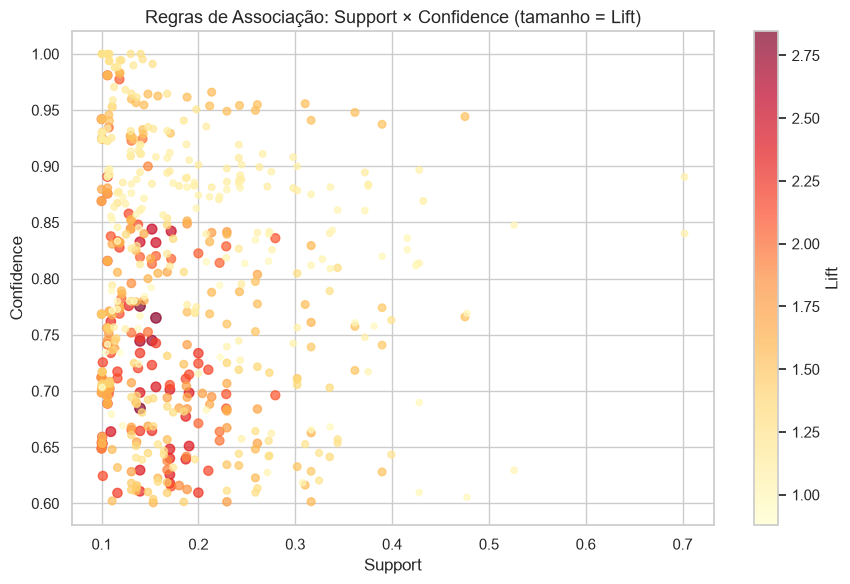

In [26]:
# --------------------------------------------------------------
# 6.2 Visualização das Regras de Associação
# --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd',
    s=rules['lift'] * 20, alpha=0.7
)
plt.colorbar(scatter, ax=ax, label='Lift')
ax.set_title('Regras de Associação: Support × Confidence (tamanho = Lift)', fontsize=13)
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
plt.tight_layout()
plt.show()

Outliers detectados pelo LOF: 73 (5.0%)


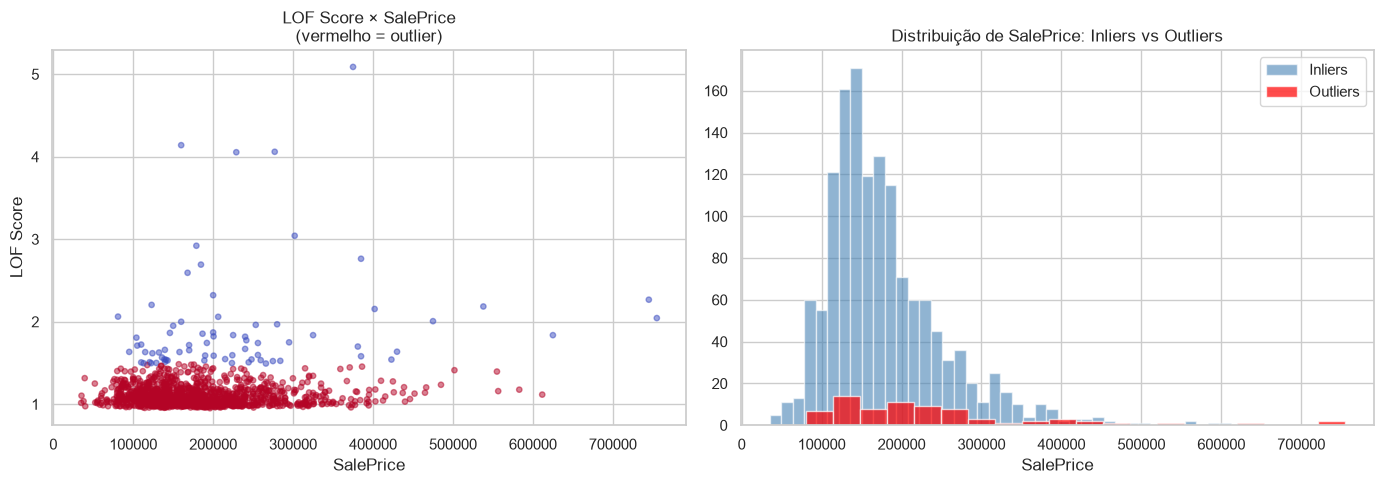

In [27]:
# --------------------------------------------------------------
# 6.3 Análise de Outlier — Local Outlier Factor (LOF)
# --------------------------------------------------------------
top10_features = importances.nlargest(10).index.tolist()
X_lof = scaler.fit_transform(df_fe[top10_features])

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_lof)  # -1 = outlier, 1 = inlier
lof_scores = -lof.negative_outlier_factor_

n_outliers = (lof_labels == -1).sum()
print(f'Outliers detectados pelo LOF: {n_outliers} ({n_outliers/len(df_fe)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Outlier score vs SalePrice
axes[0].scatter(
    df_fe['SalePrice'], lof_scores,
    c=lof_labels, cmap='coolwarm', alpha=0.5, s=15
)
axes[0].set_title('LOF Score × SalePrice\n(vermelho = outlier)')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('LOF Score')

# Distribuição do SalePrice: inliers vs outliers
inlier_prices  = df_fe.loc[lof_labels == 1, 'SalePrice']
outlier_prices = df_fe.loc[lof_labels == -1, 'SalePrice']
axes[1].hist(inlier_prices, bins=40, alpha=0.6, label='Inliers', color='steelblue')
axes[1].hist(outlier_prices, bins=20, alpha=0.7, label='Outliers', color='red')
axes[1].set_title('Distribuição de SalePrice: Inliers vs Outliers')
axes[1].set_xlabel('SalePrice')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 7️⃣ Visualização de Dados — Painel de Resultados

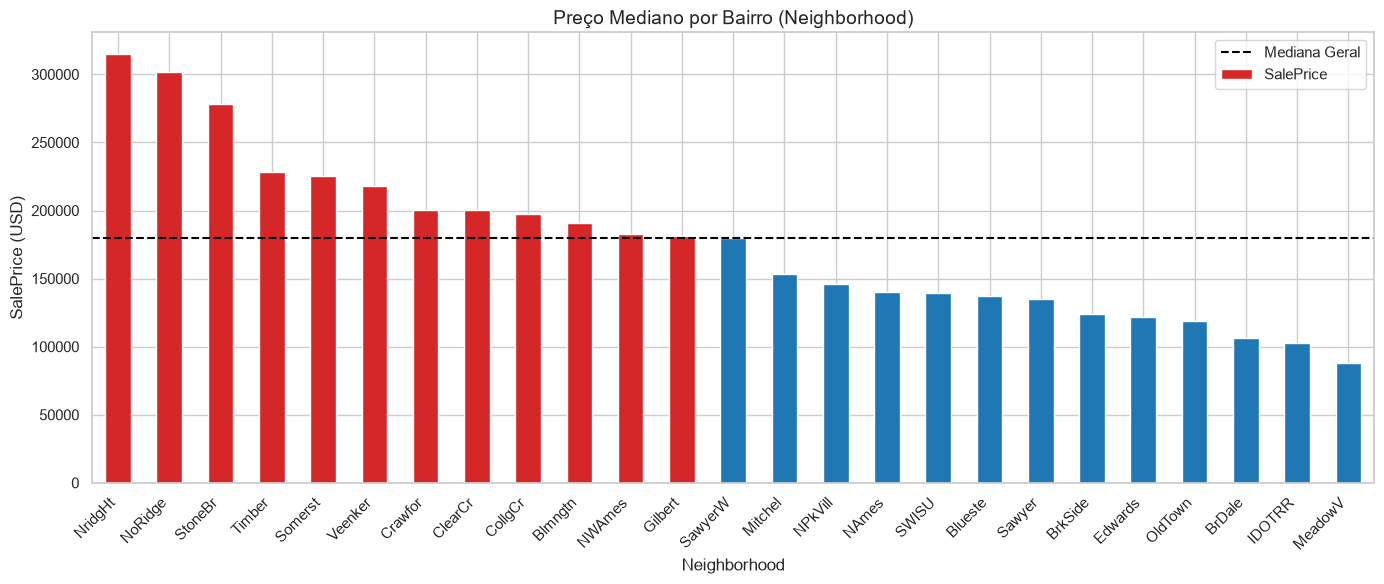

In [28]:
# --------------------------------------------------------------
# 7.1 SalePrice por bairro (Neighborhood)
# --------------------------------------------------------------
neighborhood_price = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#d62728' if p > neighborhood_price.median() else '#1f77b4'
          for p in neighborhood_price]
neighborhood_price.plot(kind='bar', ax=ax, color=colors)
ax.axhline(neighborhood_price.median(), color='black', linestyle='--', label='Mediana Geral')
ax.set_title('Preço Mediano por Bairro (Neighborhood)', fontsize=14)
ax.set_ylabel('SalePrice (USD)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

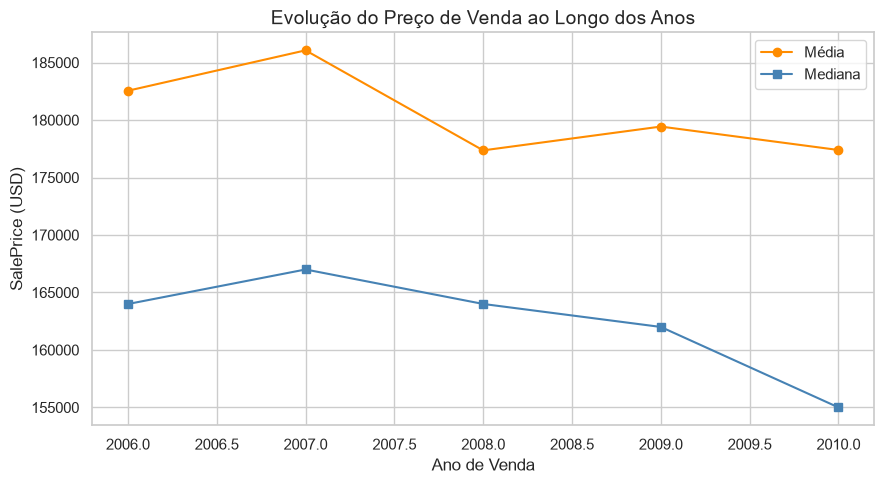

In [29]:
# --------------------------------------------------------------
# 7.2 SalePrice ao longo do tempo
# --------------------------------------------------------------
time_price = df.groupby('YrSold')['SalePrice'].agg(['mean', 'median'])

fig, ax = plt.subplots(figsize=(9, 5))
time_price['mean'].plot(ax=ax, marker='o', label='Média', color='darkorange')
time_price['median'].plot(ax=ax, marker='s', label='Mediana', color='steelblue')
ax.set_title('Evolução do Preço de Venda ao Longo dos Anos', fontsize=14)
ax.set_xlabel('Ano de Venda')
ax.set_ylabel('SalePrice (USD)')
ax.legend()
plt.tight_layout()
plt.show()

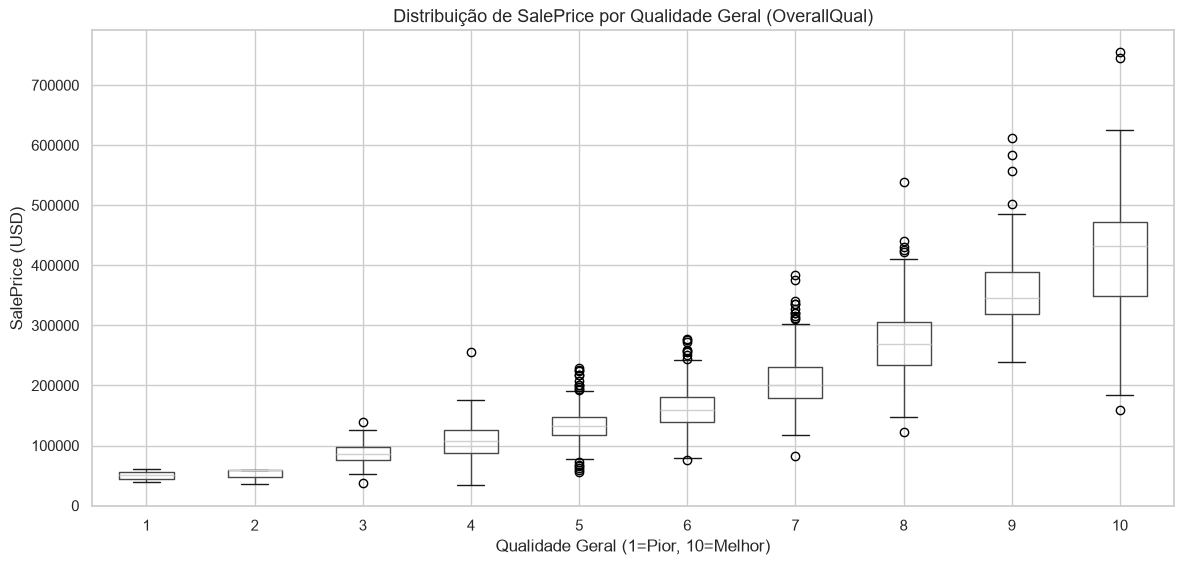

In [30]:
# --------------------------------------------------------------
# 7.3 Boxplot: SalePrice por qualidade geral (OverallQual)
# --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column='SalePrice', by='OverallQual', ax=ax)
ax.set_title('Distribuição de SalePrice por Qualidade Geral (OverallQual)', fontsize=13)
ax.set_xlabel('Qualidade Geral (1=Pior, 10=Melhor)')
ax.set_ylabel('SalePrice (USD)')
plt.suptitle('')
plt.tight_layout()
plt.show()

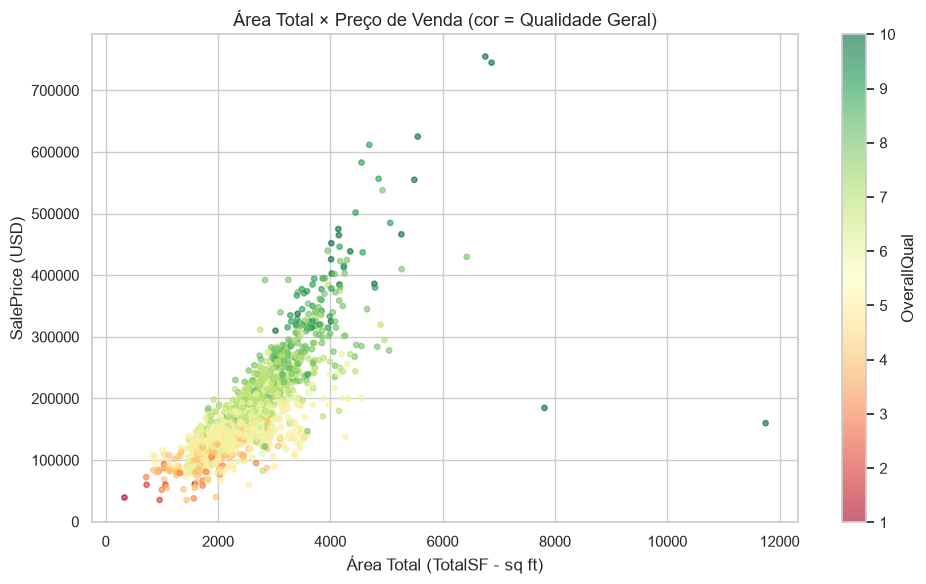

In [31]:
# --------------------------------------------------------------
# 7.4 Scatter: TotalSF × SalePrice colorido por OverallQual
# --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    df_fe['TotalSF'], df_fe['SalePrice'],
    c=df_fe['OverallQual'], cmap='RdYlGn',
    alpha=0.6, s=15
)
plt.colorbar(sc, ax=ax, label='OverallQual')
ax.set_title('Área Total × Preço de Venda (cor = Qualidade Geral)', fontsize=13)
ax.set_xlabel('Área Total (TotalSF - sq ft)')
ax.set_ylabel('SalePrice (USD)')
plt.tight_layout()
plt.show()

In [32]:
# --------------------------------------------------------------
# 7.5 TABELA FINAL: Comparação de todos os modelos
# --------------------------------------------------------------
print('=' * 60)
print('📊 COMPARAÇÃO FINAL DOS MODELOS')
print('=' * 60)

print('\n--- REGRESSÃO ---')
reg_compare = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R²': [r2_lr, r2_rf]
}).set_index('Modelo').round(4)
print(reg_compare)

print('\n--- CLASSIFICAÇÃO ---')
print(df_results)

print('\n--- NÃO SUPERVISIONADO ---')
print(f'K-Means: {K_BEST} clusters identificados')
print(f'PCA: {n_95} componentes explicam 95% da variância')
print(f'LOF: {n_outliers} outliers detectados ({n_outliers/len(df_fe)*100:.1f}%)')
print(f'Apriori: {len(rules)} regras de associação geradas')

📊 COMPARAÇÃO FINAL DOS MODELOS

--- REGRESSÃO ---
                     MAE    RMSE      R²
Modelo                                  
Regressão Linear  0.1065  0.1548  0.8715
Random Forest     0.0966  0.1445  0.8882

--- CLASSIFICAÇÃO ---
                     Accuracy  Precision  Recall  F1-Score
Regressão Logística    0.9452     0.9259  0.9542    0.9398
KNN                    0.9452     0.9389  0.9389    0.9389
Árvore de Decisão      0.8870     0.8500  0.9084    0.8782
Random Forest          0.9418     0.9254  0.9466    0.9358

--- NÃO SUPERVISIONADO ---
K-Means: 4 clusters identificados
PCA: 55 componentes explicam 95% da variância
LOF: 73 outliers detectados (5.0%)
Apriori: 546 regras de associação geradas


---
## ✅ Conclusões

- **EDA**: O dataset possui 81 variáveis. As mais correlacionadas com o preço são `OverallQual`, `GrLivArea` e `TotalBsmtSF`. A variável alvo apresenta assimetria positiva, corrigida com transformação log.
- **Feature Engineering**: Criamos `TotalSF`, `HouseAge`, `YearsSinceRemodel` e `TotalBath`. Valores faltantes foram tratados e variáveis categóricas codificadas.
- **Regressão**: O Random Forest supera a Regressão Linear com R² significativamente maior, indicando que relações não-lineares são importantes.
- **Classificação**: Todos os modelos obtiveram boa acurácia. Random Forest e Árvore de Decisão se destacaram pelo F1-Score.
- **K-Means**: Identificou 4 grupos distintos de casas com perfis de preço diferentes.
- **PCA**: A maior parte da variância é capturada em relativamente poucos componentes, confirmando que as features têm correlações fortes.
- **LOF**: Detectou outliers que geralmente correspondem a casas de preço muito elevado ou com características atípicas.
- **Apriori**: Revelou associações entre qualidade da cozinha, do exterior e faixa de preço.
